# Exploração e Pré-processamento

Este notebook apresenta a análise exploratória e o pré-processamento do dataset de diabetes, com foco na compreensão da base, identificação de inconsistências e definição das transformações necessárias para a modelagem.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid', palette='deep')

## 1. Carregamento da base


In [2]:
DATA_PATH = '../dataset/diabetes.csv'
df = pd.read_csv(DATA_PATH)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.60,0.63,50,1
1,1,85,66,29,0,26.60,0.35,31,0
2,8,183,64,0,0,23.30,0.67,32,1
3,1,89,66,23,94,28.10,0.17,21,0
4,0,137,40,35,168,43.10,2.29,33,1


## 2. Inspeção inicial


In [3]:
print('Shape:', df.shape)
print('Colunas:')
print(df.columns.tolist())

print('Info:')
df.info()

print('Nulos por coluna:')
display(df.isnull().sum().to_frame('nulos'))

print('Duplicados:', df.duplicated().sum())

Shape: (768, 9)
Colunas:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
Nulos por coluna:


,nulos
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Duplicados: 0


A base possui 768 registros e 9 colunas, todas em formato numérico. Não foram identificados valores nulos formais nem registros duplicados, embora isso não elimine a possibilidade de inconsistências semânticas nos dados.


## 3. Análise da variável-alvo


In [4]:
target_summary = pd.DataFrame({
    'contagem': df['Outcome'].value_counts(),
    'percentual': df['Outcome'].value_counts(normalize=True) * 100
})
target_summary.to_csv('../results/target-summary.csv', index=True)
target_summary

,contagem,percentual
Outcome,,
0,500,65.10
1,268,34.90


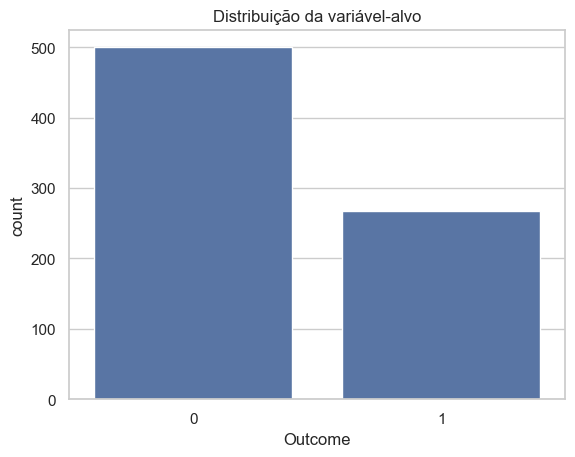

In [5]:
ax = sns.countplot(data=df, x='Outcome')
ax.set_title('Distribuição da variável-alvo')
plt.savefig('../figures/distribuicao-outcome.png', bbox_inches='tight', dpi=300)
plt.show()

A distribuição da variável-alvo mostra predominância da classe negativa, com aproximadamente 65% dos registros em `Outcome = 0` e 35% em `Outcome = 1`. Esse comportamento indica desbalanceamento moderado e justifica o uso de métricas além da acurácia nas etapas de modelagem.


## 4. Estatísticas descritivas


In [6]:
desc_stats = df.describe().T[['mean', 'std', 'min', '50%', 'max']]
desc_stats.to_csv('../results/estatisticas-descritivas.csv', index=True)
desc_stats

,mean,std,min,50%,max
Pregnancies,3.85,3.37,0.00,3.00,17.00
Glucose,120.89,31.97,0.00,117.00,199.00
BloodPressure,69.11,19.36,0.00,72.00,122.00
SkinThickness,20.54,15.95,0.00,23.00,99.00
Insulin,79.80,115.24,0.00,30.50,846.00
BMI,31.99,7.88,0.00,32.00,67.10
DiabetesPedigreeFunction,0.47,0.33,0.08,0.37,2.42
Age,33.24,11.76,21.00,29.00,81.00
Outcome,0.35,0.48,0.00,0.00,1.00


As estatísticas descritivas mostram diferenças relevantes de escala entre os atributos e valores mínimos iguais a zero em variáveis clínicas como `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` e `BMI`, indicando possível presença de valores ausentes disfarçados.


## 5. Zeros suspeitos


In [7]:
zero_suspect_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

zero_summary = pd.DataFrame({
    'zeros': (df[zero_suspect_cols] == 0).sum()
})

zero_summary['percentual_zeros'] = (zero_summary['zeros'] / len(df)) * 100
zero_summary = zero_summary.sort_values(by='percentual_zeros', ascending=False)

zero_summary.to_csv('../results/zero-summary.csv', index=True)

zero_summary

,zeros,percentual_zeros
Insulin,374,48.70
SkinThickness,227,29.56
BloodPressure,35,4.56
BMI,11,1.43
Glucose,5,0.65


A análise dos zeros suspeitos mostra maior concentração em `Insulin` e `SkinThickness`, reforçando a interpretação de que parte desses valores pode representar ausência de medição, e não observações clínicas reais.


## 6. Distribuições relevantes


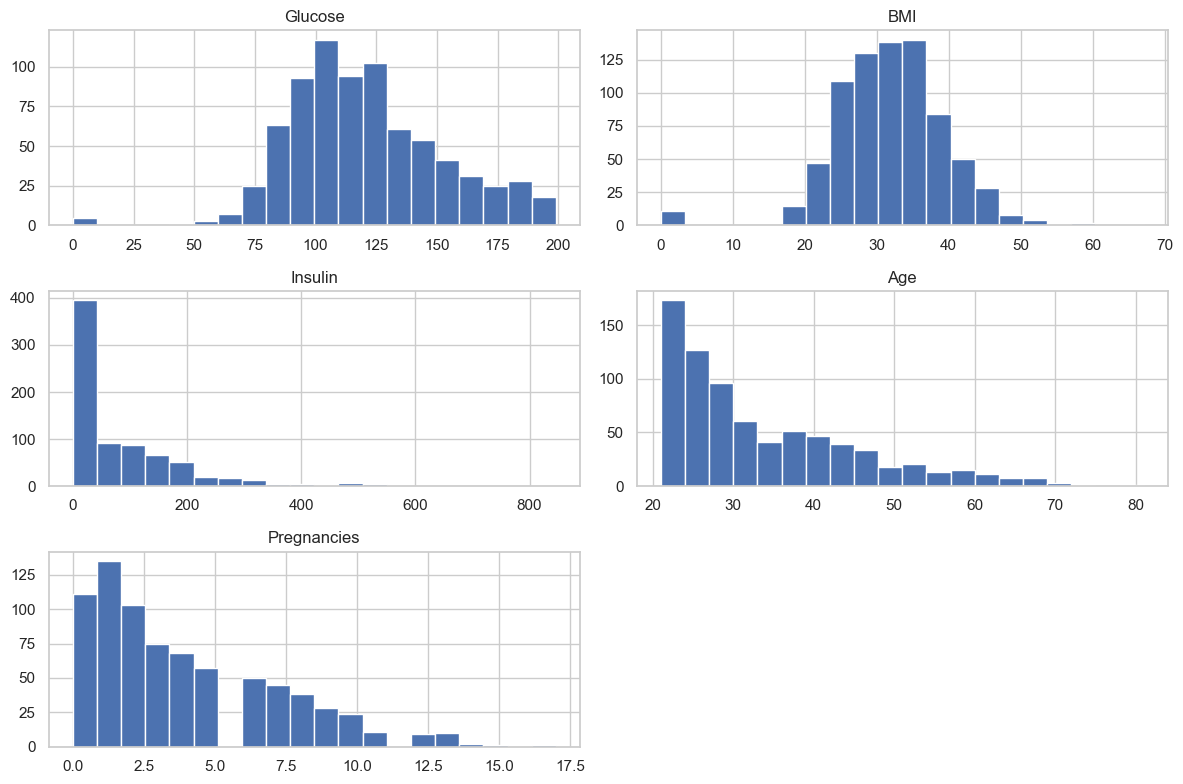

In [8]:
main_features = ['Glucose', 'BMI', 'Insulin', 'Age', 'Pregnancies']

df[main_features].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

As distribuições mostram comportamento mais estável em variáveis como `Glucose` e `BMI`, enquanto `Insulin` apresenta forte concentração de zeros, assimetria e maior sensibilidade a valores extremos.


## 7. Comparação com a classe-alvo


In [9]:
mean_by_outcome = df.groupby('Outcome')[main_features].mean()
mean_by_outcome.to_csv('../results/media-por-outcome.csv', index=True)
mean_by_outcome

,Glucose,BMI,Insulin,Age,Pregnancies
Outcome,,,,,
0,109.98,30.30,68.79,31.19,3.30
1,141.26,35.14,100.34,37.07,4.87


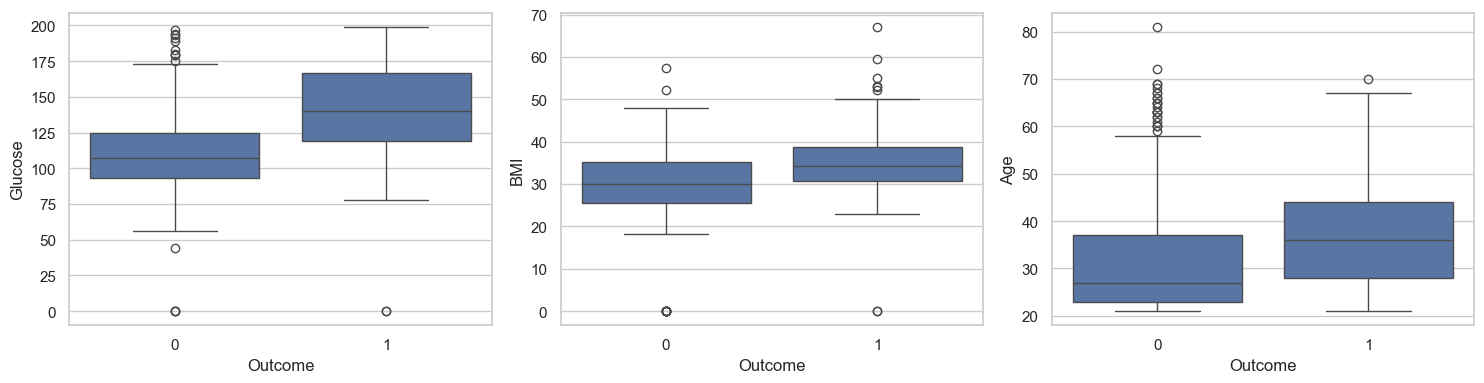

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=df, x='Outcome', y='Glucose', ax=axes[0])
sns.boxplot(data=df, x='Outcome', y='BMI', ax=axes[1])
sns.boxplot(data=df, x='Outcome', y='Age', ax=axes[2])

plt.tight_layout()
plt.show()

A comparação por classe mostra que variáveis como `Glucose`, `BMI` e `Age` apresentam valores mais altos no grupo com `Outcome = 1`, indicando potencial discriminativo para a tarefa de classificação.


## 8. Correlação


In [11]:
corr = df.corr(numeric_only=True)

corr_outcome = corr['Outcome'].sort_values(ascending=False).to_frame('correlacao_com_outcome')
corr_outcome.to_csv('../results/correlacao-com-outcome.csv', index=True)

corr_outcome

,correlacao_com_outcome
Outcome,1.00
Glucose,0.47
BMI,0.29
Age,0.24
Pregnancies,0.22
DiabetesPedigreeFunction,0.17
Insulin,0.13
SkinThickness,0.07
BloodPressure,0.07


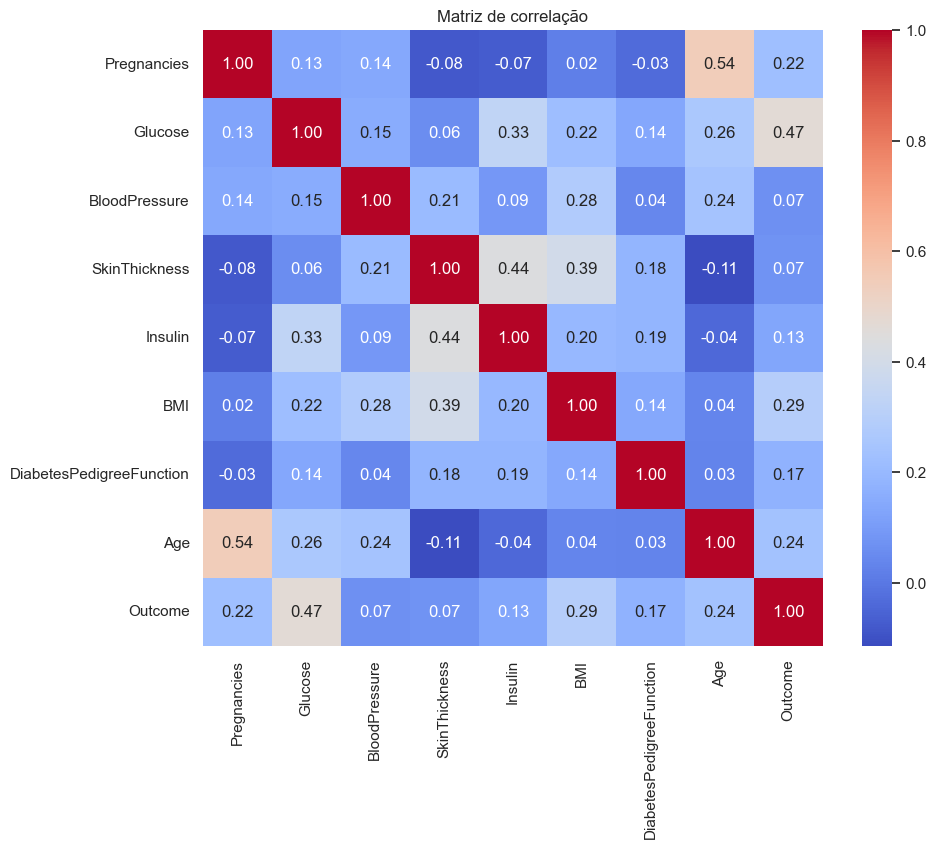

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlação')
plt.savefig('../figures/matriz-correlacao.png', bbox_inches='tight', dpi=300)
plt.show()

A análise de correlação reforça o destaque de `Glucose` como variável mais relacionada à classe-alvo, seguida por `BMI`, `Age` e `Pregnancies`. As magnitudes observadas não indicam multicolinearidade extrema entre os atributos.


## 9. Estratégia de pré-processamento


In [13]:
X = df.drop(columns='Outcome').copy()
y = df['Outcome']

X[zero_suspect_cols] = X[zero_suspect_cols].replace(0, np.nan)

X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.00,72.00,35.00,NaN,33.60,0.63,50
1,1,85.00,66.00,29.00,NaN,26.60,0.35,31
2,8,183.00,64.00,NaN,NaN,23.30,0.67,32
3,1,89.00,66.00,23.00,94.00,28.10,0.17,21
4,0,137.00,40.00,35.00,168.00,43.10,2.29,33


Com base na exploração realizada, o pré-processamento adotado para a modelagem considera o tratamento de zeros clinicamente suspeitos como valores ausentes, seguido de imputação por mediana e padronização das variáveis numéricas em pipeline.


## 10. Conclusão

A exploração dos dados permitiu identificar desbalanceamento moderado na variável-alvo, presença de zeros suspeitos em atributos clínicos relevantes e diferenças importantes de escala entre as variáveis. As análises também mostraram que `Glucose`, `BMI` e `Age` possuem maior potencial discriminativo para o problema. Com base nesses achados, foi definida uma estratégia de pré-processamento consistente, que servirá de base para a etapa de modelagem.
